# Plot1 - CarbonSavings vs. MakeSpan

In [1]:
import pandas as pd
import glob
import os

root_dir = f"../Logs/GeneralExp"

# Define the pattern
pattern = "10J_5S_3O_MeanOp=7_v*.csv"

# Get list of matching files
csv_files = glob.glob(f"{root_dir}/{pattern}")

# Read and concatenate all files
df_union = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)

print(f"✅ Loaded and merged {len(csv_files)} files. Final shape: {df_union.shape}")

✅ Loaded and merged 8 files. Final shape: (4000, 22)


In [3]:
df_logs = df_union[["Instance", "IsCarbonAware", "Horizon", "MaxMakeSpan", "MinMakeSpan", "SlackCoeff", "Makespan", "CarbonConsumption(g)"]]

In [4]:
df_logs.head(12)

,Instance,IsCarbonAware,Horizon,MaxMakeSpan,MinMakeSpan,SlackCoeff,Makespan,CarbonConsumption(g)
0,0,False,192,192,31,1.0,31,12934.00
1,0,True,192,192,31,2.0,180,7287.25
2,0,True,192,192,31,1.0,180,7305.75
3,0,True,192,192,31,1.5,180,7444.75
4,1,False,192,192,48,1.0,48,20627.00
5,1,True,192,192,48,1.5,192,12326.75
6,1,True,192,192,48,1.0,192,12208.50
7,1,True,192,192,48,2.0,192,12326.75
8,2,False,192,192,49,1.0,49,21578.25
9,2,True,192,192,49,1.5,192,13101.00


In [5]:
baseline = df_logs[df_logs["IsCarbonAware"] == False][["Makespan"]]

In [ ]:
import numpy as np
# np.average(baseline["Makespan"])
np.std(baseline["Makespan"])

np.float64(43.174)

In [8]:
baseline.head(2)

,Makespan
0,14
6,21


In [60]:

# First, get baseline carbon consumption per instance where IsCarbonAware is False
baseline = df_logs[df_logs["IsCarbonAware"] == False][["Instance", "CarbonConsumption(g)"]]
baseline = baseline.rename(columns={"CarbonConsumption(g)": "BaselineCarbon"})
# Merge it back to original df to align baseline carbon for each instance
df_logs = df_logs.merge(baseline, on="Instance", how="left")
# Calculate savings
df_logs["CarbonSavings(%)"] = ((df_logs["BaselineCarbon"] - df_logs["CarbonConsumption(g)"]) / df_logs["BaselineCarbon"]) * 100
df_logs.drop(columns=["BaselineCarbon"], inplace=True)
# Optional: round to 2 decimal places
df_logs["CarbonSavings(%)"] = df_logs["CarbonSavings(%)"].round(2)


In [61]:
df_logs.head(12)

,Instance,IsCarbonAware,Horizon,MaxMakeSpan,MinMakeSpan,Makespan,CarbonConsumption(g),CarbonSavings(%)
0,0,False,288,288,14,14,745.00,0.00
1,0,True,288,14,14,14,745.00,0.00
2,0,True,288,28,14,23,745.00,0.00
3,0,True,288,70,14,20,745.00,0.00
4,0,True,288,140,14,17,745.00,0.00
5,0,True,288,288,14,264,355.83,52.24
6,1,False,288,288,21,21,1189.75,0.00
7,1,True,288,21,21,21,1187.00,0.23
8,1,True,288,42,21,24,1187.00,0.23
9,1,True,288,105,21,24,1187.00,0.23


In [62]:
import pandas as pd

# Filter only carbon-aware rows
df_filtered = df_logs[df_logs["IsCarbonAware"] == True].copy()

# Compute the ratio and replace with 'Whole Day' when MaxMakeSpan == Horizon
df_filtered["x_label"] = df_filtered.apply(
    lambda row: "Whole Day" if row["MaxMakeSpan"] == row["Horizon"] else row["MaxMakeSpan"] // row["MinMakeSpan"],
    axis=1
)

# Group by x_label and compute average CarbonSavings(%)
df_plot = df_filtered.groupby("x_label")["CarbonSavings(%)"].mean().reset_index()

# Ensure ordering for plotting
df_plot["x_order"] = df_plot["x_label"].apply(lambda x: 999 if x == "Whole Day" else x)
df_plot = df_plot.sort_values("x_order").drop(columns="x_order")

In [68]:
import pandas as pd

# Filter for carbon-aware runs only
df_box = df_logs[df_logs["IsCarbonAware"] == True].copy()

# Create a new column for the ratio
df_box["MakeSpanRatio"] = df_box["MaxMakeSpan"] / df_box["MinMakeSpan"]

# Replace ratios that are equal to Horizon with a label
df_box["MakeSpanRatio"] = df_box.apply(
    lambda row: "Whole Day" if row["MaxMakeSpan"] == row["Horizon"] else row["MakeSpanRatio"],
    axis=1
)

# Ensure consistent type for seaborn (categorical plot)
df_box["MakeSpanRatio"] = df_box["MakeSpanRatio"].astype(str)

In [70]:
df_box.head(8)

,Instance,IsCarbonAware,Horizon,MaxMakeSpan,MinMakeSpan,Makespan,CarbonConsumption(g),CarbonSavings(%),MakeSpanRatio
1,0,True,288,14,14,14,745.00,0.00,1.0
2,0,True,288,28,14,23,745.00,0.00,2.0
3,0,True,288,70,14,20,745.00,0.00,5.0
4,0,True,288,140,14,17,745.00,0.00,10.0
5,0,True,288,288,14,264,355.83,52.24,Whole Day
7,1,True,288,21,21,21,1187.00,0.23,1.0
8,1,True,288,42,21,24,1187.00,0.23,2.0
9,1,True,288,105,21,24,1187.00,0.23,5.0


In [63]:
df_plot

,x_label,CarbonSavings(%)
0,1,0.675263
1,2,0.674194
2,5,0.733635
3,10,29.430516
4,Whole Day,54.448092


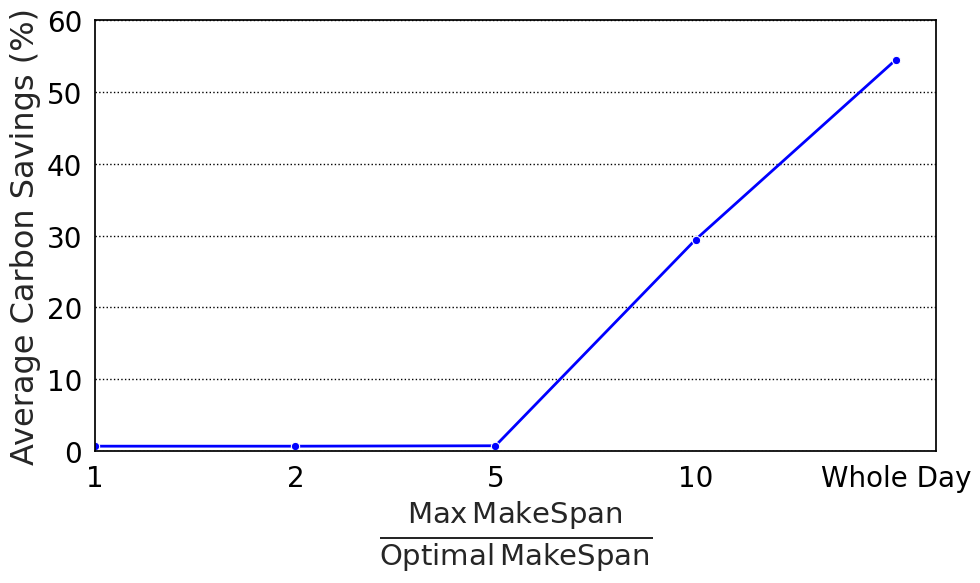

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

# Seaborn & matplotlib styling
sns.set(style="whitegrid", font="DejaVu Sans", rc={"mathtext.fontset": "dejavusans"})

# Ensure 'x_label' is treated as string (categorical)
df_plot["x_label"] = df_plot["x_label"].astype(str)

plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=df_plot,
    x="x_label",
    y="CarbonSavings(%)",
    marker="o",
    linewidth=2,
    color="blue"
)

# Labels
ax.set_xlabel(r"$\frac{\mathrm{Max\,MakeSpan}}{\mathrm{Optimal\,MakeSpan}}$", fontsize=30)
ax.set_ylabel("Average Carbon Savings (%)", fontsize=23)

# Axis limits and tick font sizes
ax.set_ylim(0, 60)
ax.set_xlim(0)
ax.tick_params(axis='x', labelsize=20, color='black')
ax.tick_params(axis='y', labelsize=20, color='black')

# Add minor ticks on y-axis every 2 units
ax.yaxis.set_minor_locator(MultipleLocator(2))
ax.tick_params(axis='y', which='minor', direction='in', length=4, color='gray')

# Grid settings
ax.grid(axis='x', visible=False)  # No x-grid
ax.grid(axis='y', which='major', color='black', linestyle=':', linewidth=1)

# Black border and ticks
ax.tick_params(axis='both', color='black', labelcolor='black')
for spine in ax.spines.values():
    spine.set_edgecolor('black')

plt.tight_layout()
plt.show()

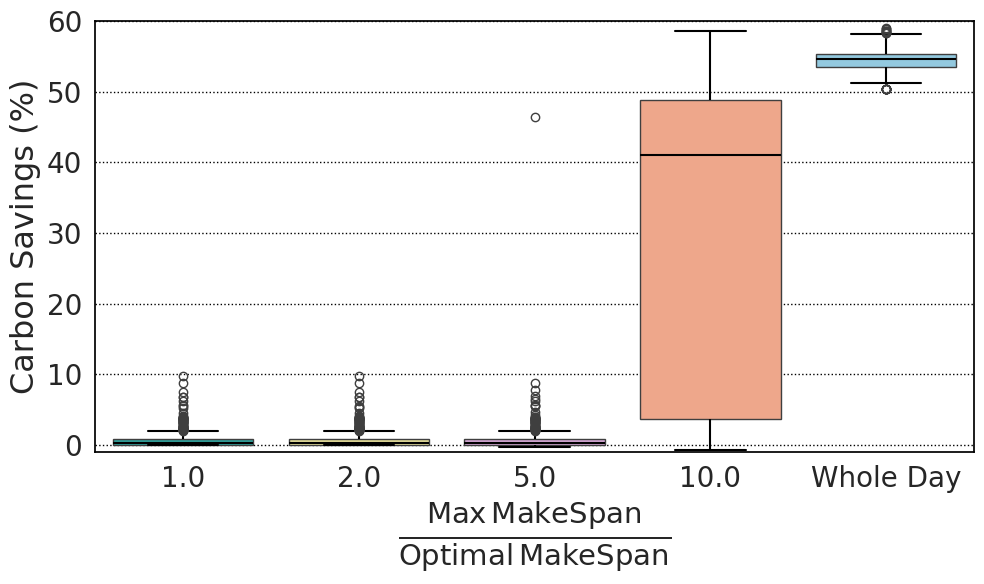

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

# Setup
sns.set(style="whitegrid", font="DejaVu Sans", rc={"mathtext.fontset": "dejavusans"})

# Dynamically match colors to number of unique categories
unique_labels = sorted(df_box["MakeSpanRatio"].unique())
inner_colors = ["lightseagreen", "khaki", "plum", "lightsalmon", "skyblue", "wheat", "orchid"]
palette = inner_colors[:len(unique_labels)]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
box = sns.boxplot(
    data=df_box,
    x="MakeSpanRatio",
    y="CarbonSavings(%)",
    hue="MakeSpanRatio",
    palette=palette,
    dodge=False,
    legend=False
)

# Axis labels
ax.set_xlabel(r"$\frac{\mathrm{Max\,MakeSpan}}{\mathrm{Optimal\,MakeSpan}}$", fontsize=30)
ax.set_ylabel("Carbon Savings (%)", fontsize=23)

# Axis ticks and limits
ax.set_ylim(-1, 60)
ax.tick_params(axis='x', labelsize=20, color='black')
ax.tick_params(axis='y', labelsize=20, color='black')

# Minor ticks
ax.yaxis.set_minor_locator(MultipleLocator(2))
ax.tick_params(axis='y', which='minor', direction='in', length=4, color='gray')

# Grid & borders
ax.grid(axis='x', visible=False)
ax.grid(axis='y', which='major', color='black', linestyle=':', linewidth=1)
for spine in ax.spines.values():
    spine.set_edgecolor('black')

# Box edges and medians
for i, patch in enumerate(ax.artists):
    patch.set_edgecolor("black")
    patch.set_linewidth(1.5)
    patch.set_facecolor(palette[i % len(palette)])
for line in ax.lines:
    line.set_color("black")
    line.set_linewidth(1.5)

plt.tight_layout()
plt.show()